# **World Happiness Report - Part 1: EDA**

This notebook is the first part of our **World Happiness** data science project in which we aim to **clean the dataset** and perform some **exploratory data analysis (EDA)**.


## Importing Dataset

We will be importing the dataset directly from kaggle (https://www.kaggle.com/datasets/unsdsn/world-happiness).

In [1]:
!pip install kaggle
!kaggle datasets download -d unsdsn/world-happiness
!unzip -o world-happiness.zip -d world_happiness_data

Dataset URL: https://www.kaggle.com/datasets/unsdsn/world-happiness
License(s): CC0-1.0




  0%|          | 0.00/36.8k [00:00<?, ?B/s]
100%|██████████| 36.8k/36.8k [00:00<00:00, 730kB/s]


Archive:  world-happiness.zip
  inflating: world_happiness_data/2015.csv  
  inflating: world_happiness_data/2016.csv  
  inflating: world_happiness_data/2017.csv  
  inflating: world_happiness_data/2018.csv  
  inflating: world_happiness_data/2019.csv  


## Data Cleaning Steps

In this section, we clean and standardize the World Happiness dataset collected from 2015 to 2019. The cleaning process includes the following key steps:

### 1. Merging Multiple CSV Files
- Loaded CSV files for each year from 2015 to 2019.
- Standardized the column names using a mapping dictionary to ensure consistency across all years.
- Selected only relevant columns common across years.
- Added a `year` column to each DataFrame.

### 2. String Standardization
- Trimmed whitespace and converted all string values (e.g., country names) to lowercase for consistency.

### 3. Combining and Aligning Data
- Merged all yearly DataFrames into a single master DataFrame.
- Ensured all selected columns are present; added missing columns like `dystopia_residual` for years where it was absent.
- Reordered and filtered columns to keep only the common and relevant ones.

### 4. Data Type Conversion
- Converted all numeric columns (e.g., `happiness_score`, `gdp_per_capita`) to numeric data types.
- Coerced any conversion errors to `NaN` for easy handling of invalid entries.

### 5. Duplicate Handling
- Dropped any duplicate rows to avoid redundancy.

### 6. Country Name Standardization
- Corrected inconsistent country names (e.g., `"macedonia"` → `"north macedonia"`).

### 7. Additional Cleaning & Anomaly Checks
- Reapplied trimming and lowercase conversion on string columns.
- Rechecked and reapplied country name corrections.
- Verified and corrected numeric columns again as needed.
- Printed summary statistics to identify anomalies and data issues.
- Checked for negative values in columns where they don’t make logical sense.
- Ensured only valid years (2015–2019) are present in the dataset.
- Identified potential outliers using the z-score method (`z > 3`).

### 8. Final Dataset Preparation
- Sorted the dataset by country name and year.
- Reset the index for clean tabular representation.
- Saved the final cleaned dataset as `world_happiness_master.csv`.

### 9. Final Dataset Checks
- Displayed dataset information, including shape, column names, missing values, and descriptive statistics.
- Counted unique countries and verified no duplicate rows remain.


Import Libraries

In [3]:
import pandas as pd
import numpy as np
from scipy import stats


Define File Paths and Column Mappings

In [4]:
file_paths = [
    "world_happiness_data/2015.csv",
    "world_happiness_data/2016.csv",
    "world_happiness_data/2017.csv",
    "world_happiness_data/2018.csv",
    "world_happiness_data/2019.csv"
]

# Standardized column mappings for each year
df_columns = {
    "2015": {
        "Country": "country",
        "Happiness Rank": "happiness_rank",
        "Happiness Score": "happiness_score",
        "Economy (GDP per Capita)": "gdp_per_capita",
        "Family": "social_support",
        "Health (Life Expectancy)": "life_expectancy",
        "Freedom": "freedom",
        "Trust (Government Corruption)": "corruption",
        "Generosity": "generosity",
        "Dystopia Residual": "dystopia_residual"
    },
    "2016": {
        "Country": "country",
        "Happiness Rank": "happiness_rank",
        "Happiness Score": "happiness_score",
        "Economy (GDP per Capita)": "gdp_per_capita",
        "Family": "social_support",
        "Health (Life Expectancy)": "life_expectancy",
        "Freedom": "freedom",
        "Trust (Government Corruption)": "corruption",
        "Generosity": "generosity",
        "Dystopia Residual": "dystopia_residual"
    },
    "2017": {
        "Country": "country",
        "Happiness.Rank": "happiness_rank",
        "Happiness.Score": "happiness_score",
        "Economy..GDP.per.Capita.": "gdp_per_capita",
        "Family": "social_support",
        "Health..Life.Expectancy.": "life_expectancy",
        "Freedom": "freedom",
        "Generosity": "generosity",
        "Trust..Government.Corruption.": "corruption",
        "Dystopia.Residual": "dystopia_residual"
    },
    "2018": {
        "Overall rank": "happiness_rank",
        "Country or region": "country",
        "Score": "happiness_score",
        "GDP per capita": "gdp_per_capita",
        "Social support": "social_support",
        "Healthy life expectancy": "life_expectancy",
        "Freedom to make life choices": "freedom",
        "Generosity": "generosity",
        "Perceptions of corruption": "corruption"
    },
    "2019": {
        "Overall rank": "happiness_rank",
        "Country or region": "country",
        "Score": "happiness_score",
        "GDP per capita": "gdp_per_capita",
        "Social support": "social_support",
        "Healthy life expectancy": "life_expectancy",
        "Freedom to make life choices": "freedom",
        "Generosity": "generosity",
        "Perceptions of corruption": "corruption"
    }
}


Load and Clean Individual Yearly Data

In [5]:
def load_and_clean_data(file_path, year, column_mapping):
    df = pd.read_csv(file_path)
    df = df.rename(columns=column_mapping)
    df = df[list(column_mapping.values())]
    df["year"] = year
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip().str.lower()
    return df


Combine All Years into One Master DataFrame

In [6]:
all_data = []
years = [2015, 2016, 2017, 2018, 2019]
for file, year in zip(file_paths, years):
    all_data.append(load_and_clean_data(file, year, df_columns[str(year)]))

df_master = pd.concat(all_data, ignore_index=True)


Standardize Columns and Handle Missing Values

In [7]:
common_columns = [
    "country", "happiness_rank", "happiness_score", "gdp_per_capita",
    "social_support", "life_expectancy", "freedom", "generosity",
    "corruption", "dystopia_residual", "year"
]

if "dystopia_residual" not in df_master.columns:
    df_master["dystopia_residual"] = pd.NA

df_master = df_master[common_columns]

numeric_cols = [
    "happiness_rank", "happiness_score", "gdp_per_capita", "social_support",
    "life_expectancy", "freedom", "generosity", "corruption", "dystopia_residual"
]
for col in numeric_cols:
    df_master[col] = pd.to_numeric(df_master[col], errors="coerce")

df_master = df_master.drop_duplicates()


Country Name Corrections

In [8]:
corrections = {
    "hong kong s.a.r., china": "hong kong",
    "northern cyprus": "cyprus",
    "north cyprus": "cyprus",
    "macedonia": "north macedonia",
    "trinidad & tobago": "trinidad and tobago",
    "taiwan province of china": "taiwan",
    "somaliland region": "somalia",
    "congo (brazzaville)": "congo",
    "congo (kinshasa)": "congo"
}
df_master["country"] = df_master["country"].replace(corrections)
df_master = df_master.sort_values(by=["country", "year"], ascending=[True, True])


Additional Cleaning & Anomaly Checks

In [9]:
num_duplicates = df_master.duplicated().sum()
print(f"Number of duplicate rows before additional cleaning: {num_duplicates}")
df_master = df_master.drop_duplicates()

string_cols = df_master.select_dtypes(include="object").columns
df_master[string_cols] = df_master[string_cols].apply(lambda x: x.str.strip().str.lower())
df_master["country"] = df_master["country"].replace(corrections)

for col in numeric_cols:
    df_master[col] = pd.to_numeric(df_master[col], errors="coerce")

print("\nSummary statistics for numeric columns:")
print(df_master[numeric_cols].describe())


Number of duplicate rows before additional cleaning: 0

Summary statistics for numeric columns:
       happiness_rank  happiness_score  gdp_per_capita  social_support  \
count      782.000000       782.000000      782.000000      782.000000   
mean        78.698210         5.379018        0.916047        1.078392   
std         45.182384         1.127456        0.407340        0.329548   
min          1.000000         2.693000        0.000000        0.000000   
25%         40.000000         4.509750        0.606500        0.869363   
50%         79.000000         5.322000        0.982205        1.124735   
75%        118.000000         6.189500        1.236187        1.327250   
max        158.000000         7.769000        2.096000        1.644000   

       life_expectancy     freedom  generosity  corruption  dystopia_residual  
count       782.000000  782.000000  782.000000  781.000000         470.000000  
mean          0.612416    0.411091    0.218576    0.125436           2.092717

Detect Negative Values and Invalid Years

In [10]:
for col in numeric_cols:
    negatives = df_master[df_master[col] < 0]
    if not negatives.empty:
        print(f"\nAnomalies found: Negative values in column '{col}':")
        print(negatives[[col, "country", "year"]])

valid_years = [2015, 2016, 2017, 2018, 2019]
invalid_years = df_master[~df_master["year"].isin(valid_years)]
if not invalid_years.empty:
    print("\nFound rows with unexpected year values:")
    print(invalid_years[["year", "country"]])
    df_master = df_master[df_master["year"].isin(valid_years)]


Outlier Detection Using Z-score

In [11]:
z_scores = np.abs(stats.zscore(df_master[numeric_cols].dropna()))
outlier_mask = (z_scores > 3).any(axis=1)
num_outliers = outlier_mask.sum()
print(f"\nNumber of potential outlier rows (z > 3): {num_outliers}")

# df_master = df_master[~df_master.index.isin(df_master[numeric_cols].dropna().index[outlier_mask])]

df_master = df_master.sort_values(by=["country", "year"], ascending=[True, True]).reset_index(drop=True)



Number of potential outlier rows (z > 3): 16


Save Final Cleaned Dataset

In [12]:
df_master.to_csv("world_happiness_master.csv", index=False)
print("\nFinal cleaned dataset saved as 'world_happiness_master.csv'")



Final cleaned dataset saved as 'world_happiness_master.csv'


Display Dataset Summary Information

In [13]:
print("\nDataset Info:")
df_master.info()

print("\nFirst 5 Rows:")
print(df_master.head())

print("\nDataset Shape (rows, columns):")
print(df_master.shape)

print("\nColumn Names:")
print(df_master.columns.tolist())

print("\nMissing Values per Column:")
print(df_master.isnull().sum())

print("\nSummary Statistics for Numerical Columns:")
print(df_master.describe())

print("\nNumber of Unique Countries:")
print(df_master["country"].nunique())

print("\nNumber of Duplicate Rows:")
print(df_master.duplicated().sum())

print("\nUnique Country Names (After Corrections):")
print(sorted(df_master["country"].unique()))



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            782 non-null    object 
 1   happiness_rank     782 non-null    int64  
 2   happiness_score    782 non-null    float64
 3   gdp_per_capita     782 non-null    float64
 4   social_support     782 non-null    float64
 5   life_expectancy    782 non-null    float64
 6   freedom            782 non-null    float64
 7   generosity         782 non-null    float64
 8   corruption         781 non-null    float64
 9   dystopia_residual  470 non-null    float64
 10  year               782 non-null    int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 67.3+ KB

First 5 Rows:
       country  happiness_rank  happiness_score  gdp_per_capita  \
0  afghanistan             153            3.575        0.319820   
1  afghanistan             154            3.

# 📊 World Happiness Report – Exploratory Data Analysis (EDA)

This analysis explores the **World Happiness Dataset (2015–2019)** using Python libraries such as **Pandas**, **Matplotlib**, **Seaborn**, and **Plotly**. It includes visual and statistical exploration of happiness scores across countries, years, and key contributing factors.

---

## 📦 1. Data Preparation

- Load the dataset `world_happiness_master.csv`.
- Import required libraries.
- Use `country_converter (coco)` to map country names to continents and ISO3 codes.

---

## 🌍 2. Top & Bottom Happiest Countries (2015–2019)

- For each year (2015–2019):
  - Extract **Top 10** happiest countries (`lowest happiness_rank`).
  - Extract **Bottom 10** least happy countries (`highest happiness_rank`).
  - Display results in the console.

---

## 📅 3. EDA for 2019

### 3a. 📈 Feature vs. Happiness Score (Scatter Plots)

- For 2019, plot **happiness_score** against:
  - `gdp_per_capita`
  - `social_support`
  - `life_expectancy`
  - `freedom`
  - `generosity`
  - `corruption`
  - `dystopia_residual`

### 3b. 🧭 Happiness Score by Continent

- Use `country_converter` to add a `continent` column.
- Create a **boxplot** of happiness scores grouped by continent.

### 3c. 🗺️ World Map of Happiness (2019)

- Convert country names to ISO3 codes.
- Plot a **choropleth map** using Plotly, where color indicates happiness score.

---

## 📈 4. Yearly Happiness Trends

### 4a. 📉 Mean Happiness Score Per Year

- Compute and plot **mean happiness score** for each year using a **line plot**.

### 4b. 📦 Score Distribution Per Year

- Use a **boxplot** to show how the distribution of scores varies across years.

---

## 🔥 5. Correlation Heatmaps (2015–2019)

- For each year, compute a **correlation matrix** among numerical features:
  - `happiness_score`, `gdp_per_capita`, `social_support`, `life_expectancy`, 
    `freedom`, `generosity`, `corruption`, `dystopia_residual`
- Plot each matrix using a **Seaborn heatmap**.

---

## 📊 6. Country-Wise Trends Over Time

- For selected countries:
  - `Norway`, `Switzerland`, `Denmark`, `Finland`, `Netherlands`
- Plot line graphs showing how each country’s happiness score changes from 2015 to 2019.

---

## 🔄 7. Multi-Year Feature Comparisons (Facet Grids)

- Use **Seaborn’s FacetGrid** to compare relationships between each feature and happiness score across different years.
- Features include:
  - `gdp_per_capita`, `social_support`, `life_expectancy`, 
    `freedom`, `generosity`, `corruption`, `dystopia_residual`

---

## 📉 8. Correlation Evolution Over Time

- For each feature, calculate its correlation with `happiness_score` per year.
- Plot a **line graph** to visualize how these correlations evolve from 2015 to 2019.

---


Import Libraries & Load Dataset

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

try:
    import country_converter as coco
except ImportError:
    raise ImportError("Please install country_converter with: pip install country_converter")

df = pd.read_csv("world_happiness_master.csv")

Top & Bottom 10 Happiest Countries per Year

In [15]:
years = [2015, 2016, 2017, 2018, 2019]

for year in years:
    df_year = df[df['year'] == year]
    top10 = df_year.nsmallest(10, 'happiness_rank')[['country', 'happiness_rank', 'happiness_score']]
    bottom10 = df_year.nlargest(10, 'happiness_rank')[['country', 'happiness_rank', 'happiness_score']]
    
    print(f"\n===== Year: {year} =====")
    print("Top 10 Happiest Countries:")
    print(top10.to_string(index=False))
    print("\nBottom 10 Happiest Countries:")
    print(bottom10.to_string(index=False))


===== Year: 2015 =====
Top 10 Happiest Countries:
    country  happiness_rank  happiness_score
switzerland               1            7.587
    iceland               2            7.561
    denmark               3            7.527
     norway               4            7.522
     canada               5            7.427
    finland               6            7.406
netherlands               7            7.378
     sweden               8            7.364
new zealand               9            7.286
  australia              10            7.284

Bottom 10 Happiest Countries:
     country  happiness_rank  happiness_score
        togo             158            2.839
     burundi             157            2.905
       syria             156            3.006
       benin             155            3.340
      rwanda             154            3.465
 afghanistan             153            3.575
burkina faso             152            3.587
 ivory coast             151            3.655
      gui

EDA for 2019 Only - Feature vs Happiness Score (Scatter Plots)

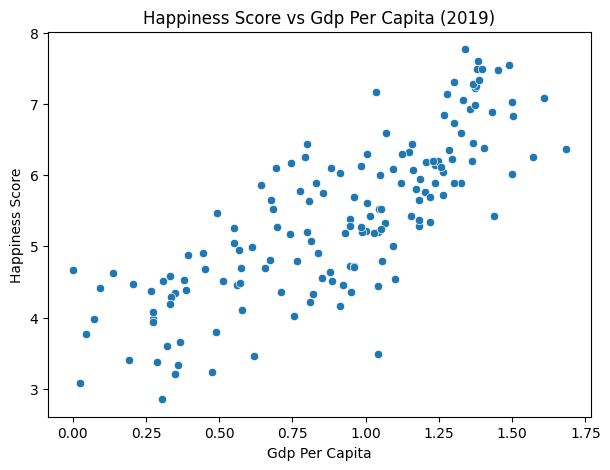

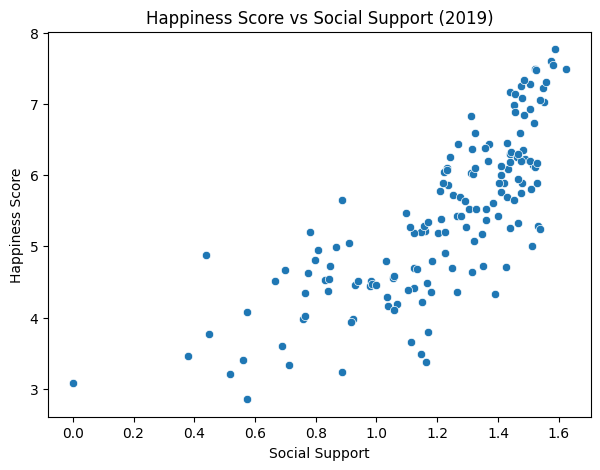

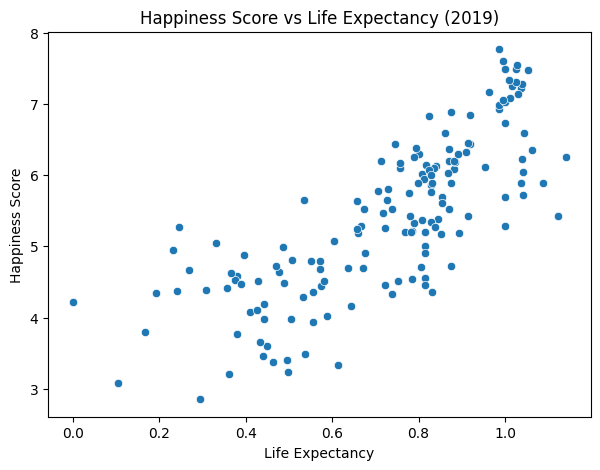

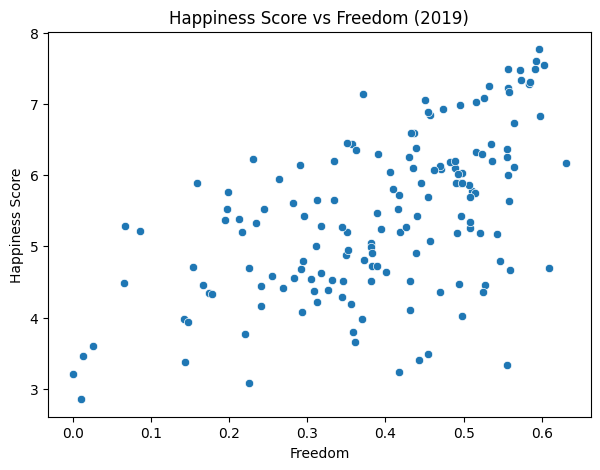

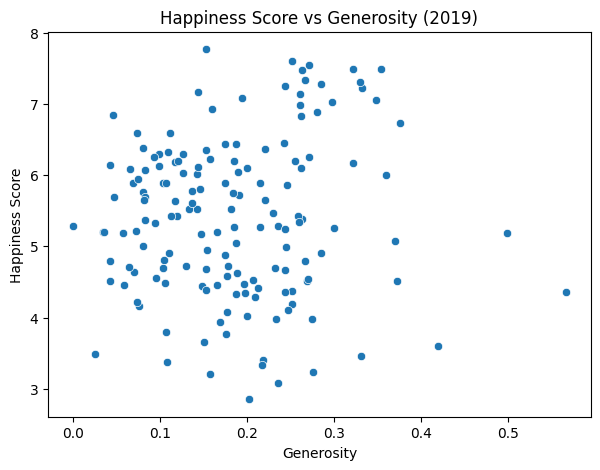

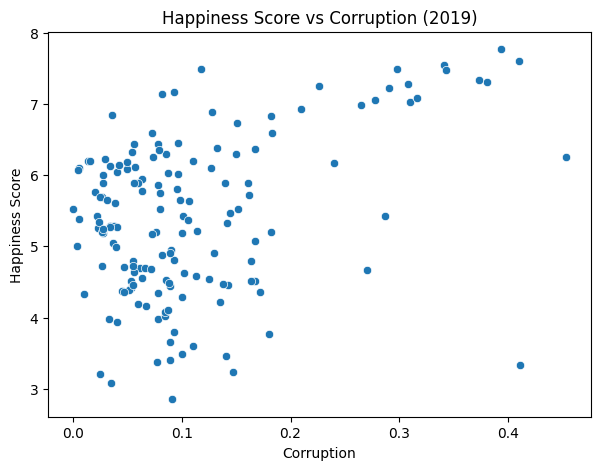

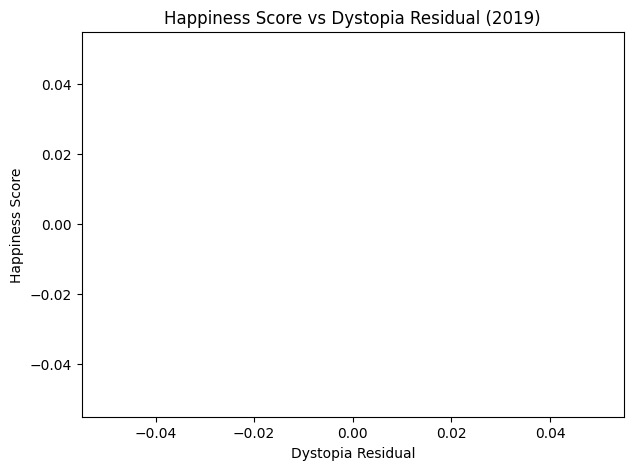

In [16]:
df_2019 = df[df['year'] == 2019].copy()

features = ["gdp_per_capita", "social_support", "life_expectancy", 
            "freedom", "generosity", "corruption", "dystopia_residual"]

for feature in features:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(x=feature, y="happiness_score", data=df_2019)
    plt.title(f"Happiness Score vs {feature.replace('_', ' ').title()} (2019)")
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel("Happiness Score")
    plt.show()

EDA for 2019 Only - Happiness Score by Continent

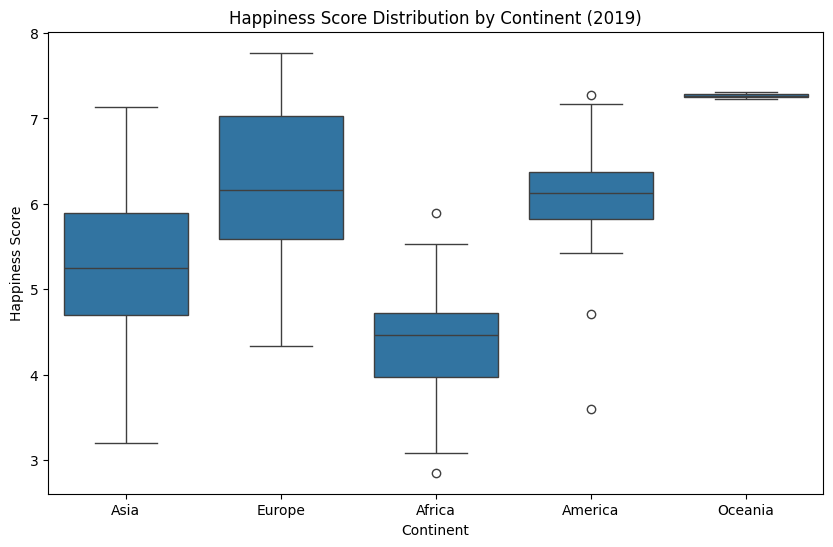

In [17]:
df_2019['continent'] = coco.convert(names=df_2019['country'], to='continent')

plt.figure(figsize=(10, 6))
sns.boxplot(x='continent', y='happiness_score', data=df_2019)
plt.title("Happiness Score Distribution by Continent (2019)")
plt.xlabel("Continent")
plt.ylabel("Happiness Score")
plt.show()

EDA for 2019 Only - Choropleth Map (World View)

In [18]:
df_2019['iso_alpha'] = coco.convert(names=df_2019['country'], to='ISO3')

fig = px.choropleth(df_2019,
                    locations='iso_alpha',
                    color='happiness_score',
                    hover_name='country',
                    color_continuous_scale='Blues',
                    title='World Happiness Score (2019)')
fig.show()

Happiness Score Trends by Year - Mean Happiness Score Over Time

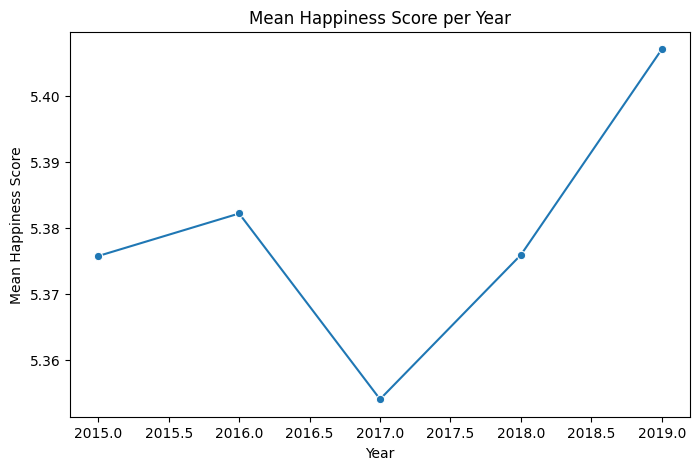

In [19]:
mean_scores = df.groupby("year")["happiness_score"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x="year", y="happiness_score", data=mean_scores, marker="o")
plt.title("Mean Happiness Score per Year")
plt.xlabel("Year")
plt.ylabel("Mean Happiness Score")
plt.show()

Happiness Score Trends by Year - Distribution of Scores by Year

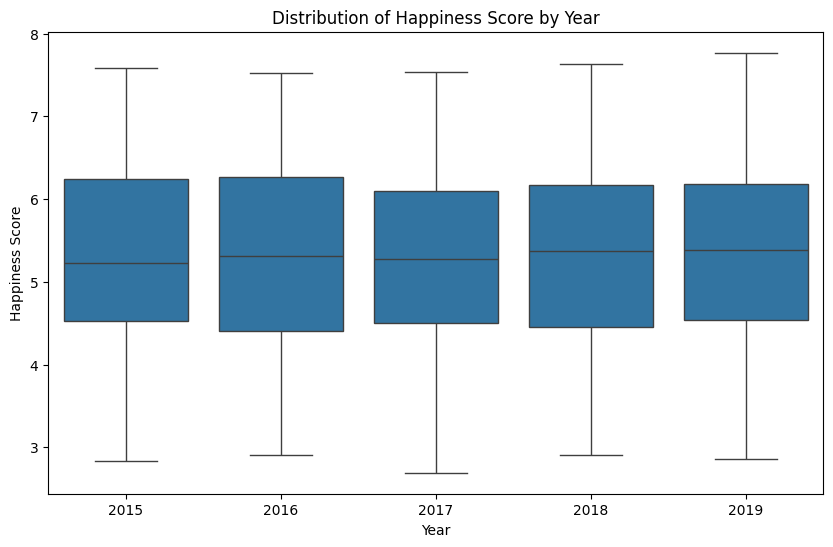

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="year", y="happiness_score", data=df)
plt.title("Distribution of Happiness Score by Year")
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.show()

Correlation Heatmaps (2015–2019)

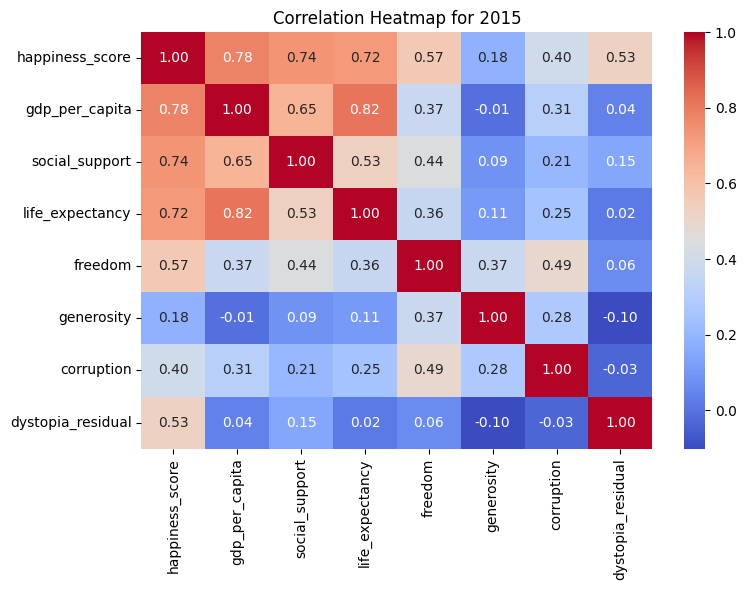

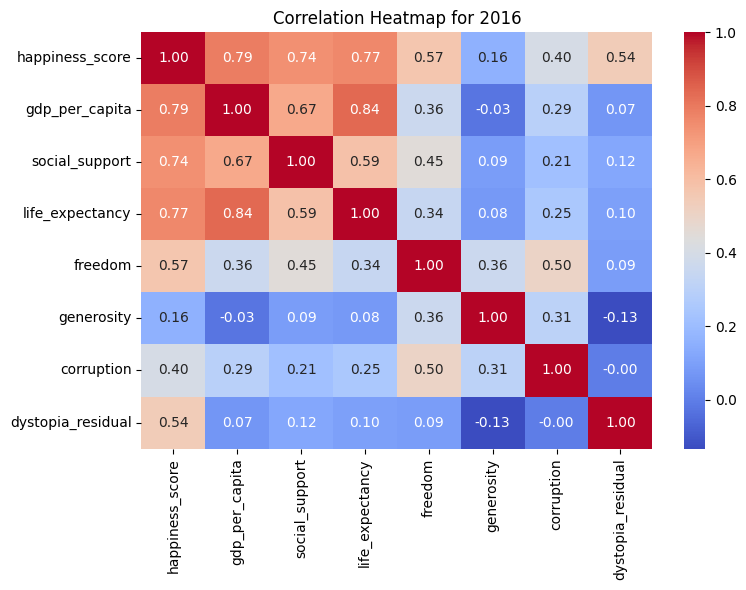

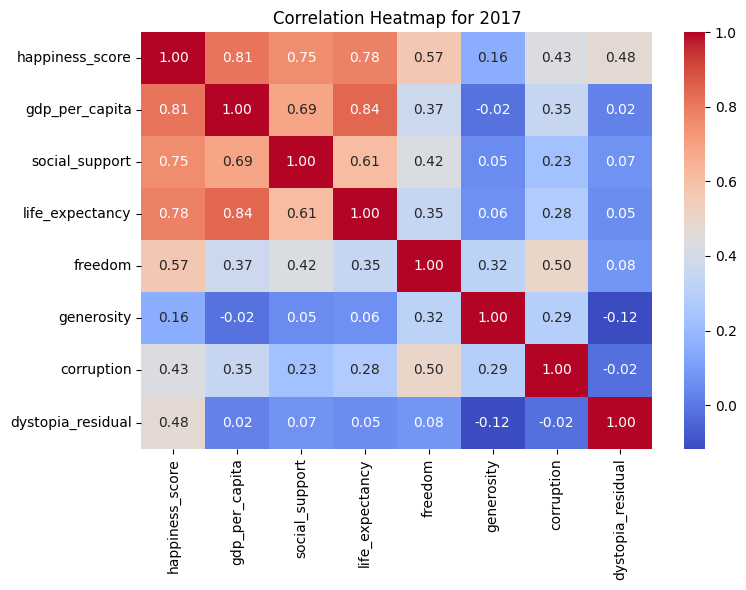

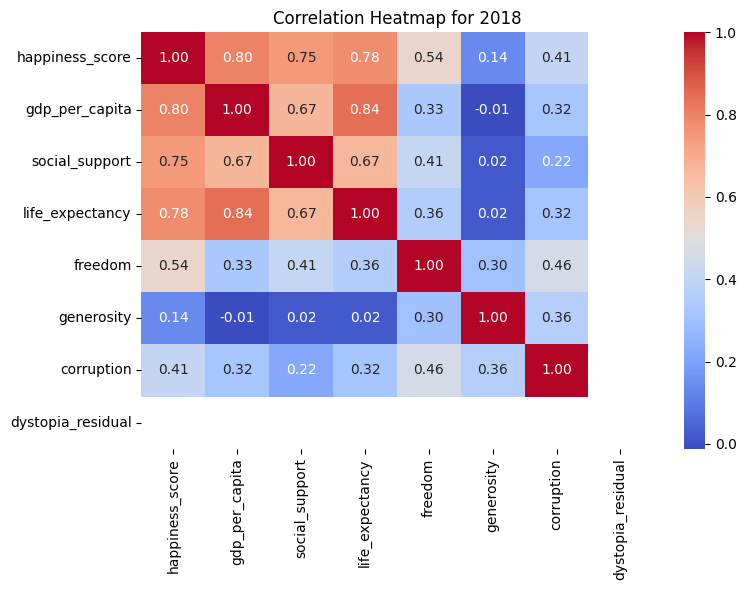

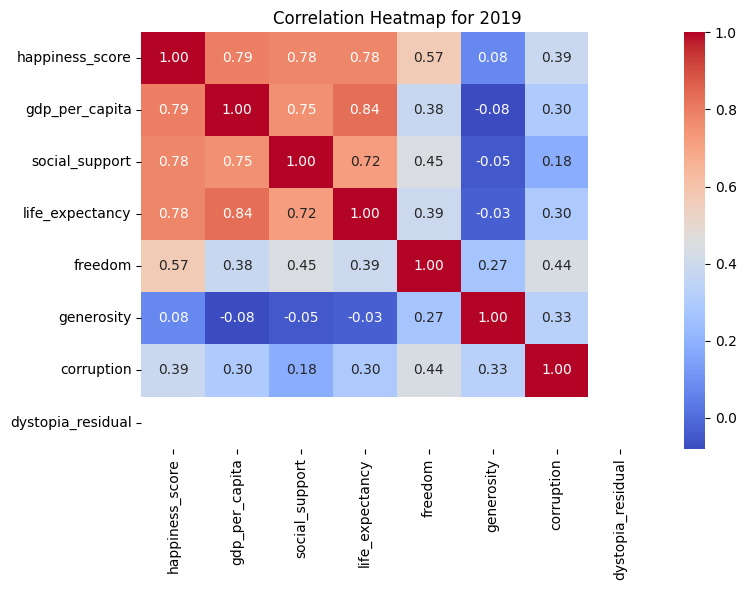

In [21]:
num_features = ["happiness_score", "gdp_per_capita", "social_support", 
                "life_expectancy", "freedom", "generosity", "corruption", "dystopia_residual"]

for year in years:
    df_year = df[df['year'] == year]
    corr = df_year[num_features].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlation Heatmap for {year}")
    plt.tight_layout()
    plt.show()

Country-Wise Trends (Line Plots)

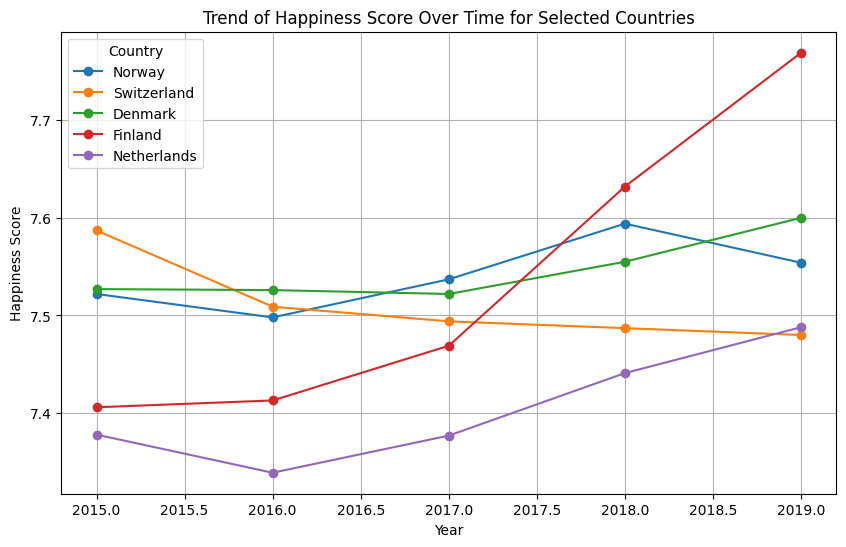

In [22]:
selected_countries = ['norway', 'switzerland', 'denmark', 'finland', 'netherlands']
df_selected = df[df['country'].isin(selected_countries)]

plt.figure(figsize=(10, 6))
for country in selected_countries:
    df_country = df_selected[df_selected['country'] == country]
    plt.plot(df_country['year'], df_country['happiness_score'], marker='o', label=country.title())

plt.title("Trend of Happiness Score Over Time for Selected Countries")
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.legend(title="Country")
plt.grid(True)
plt.show()

Multi-Year Feature Comparisons (FacetGrid)

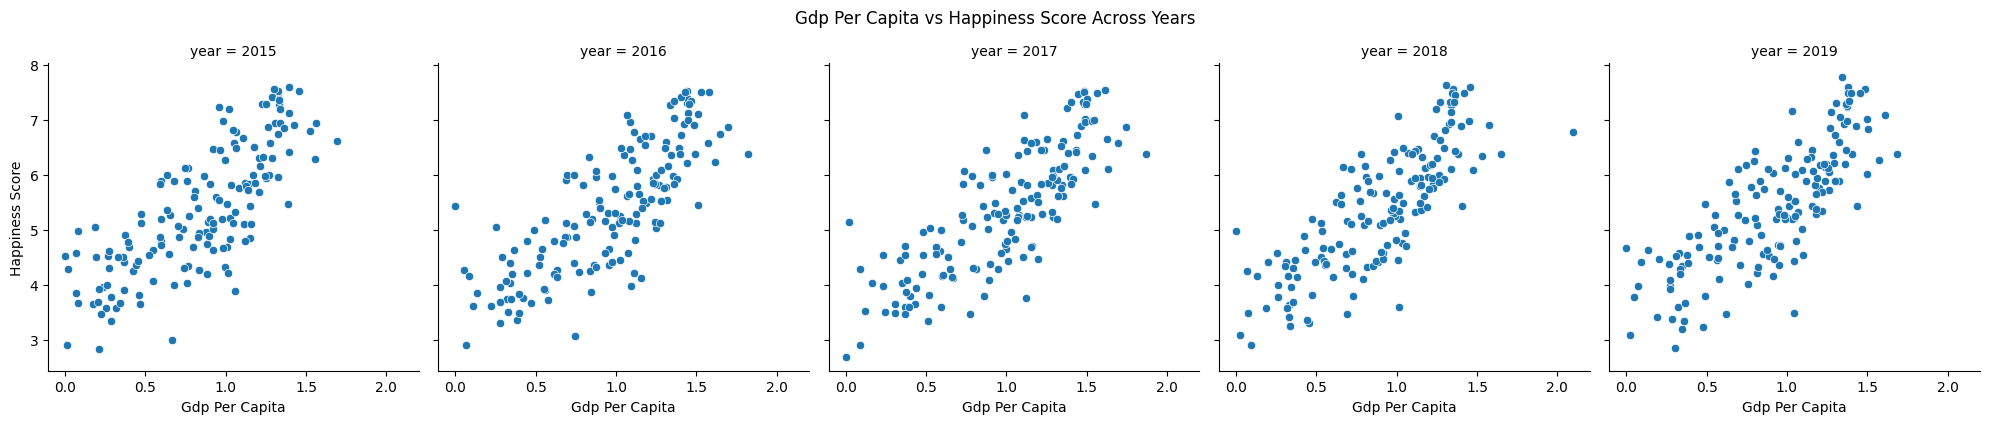

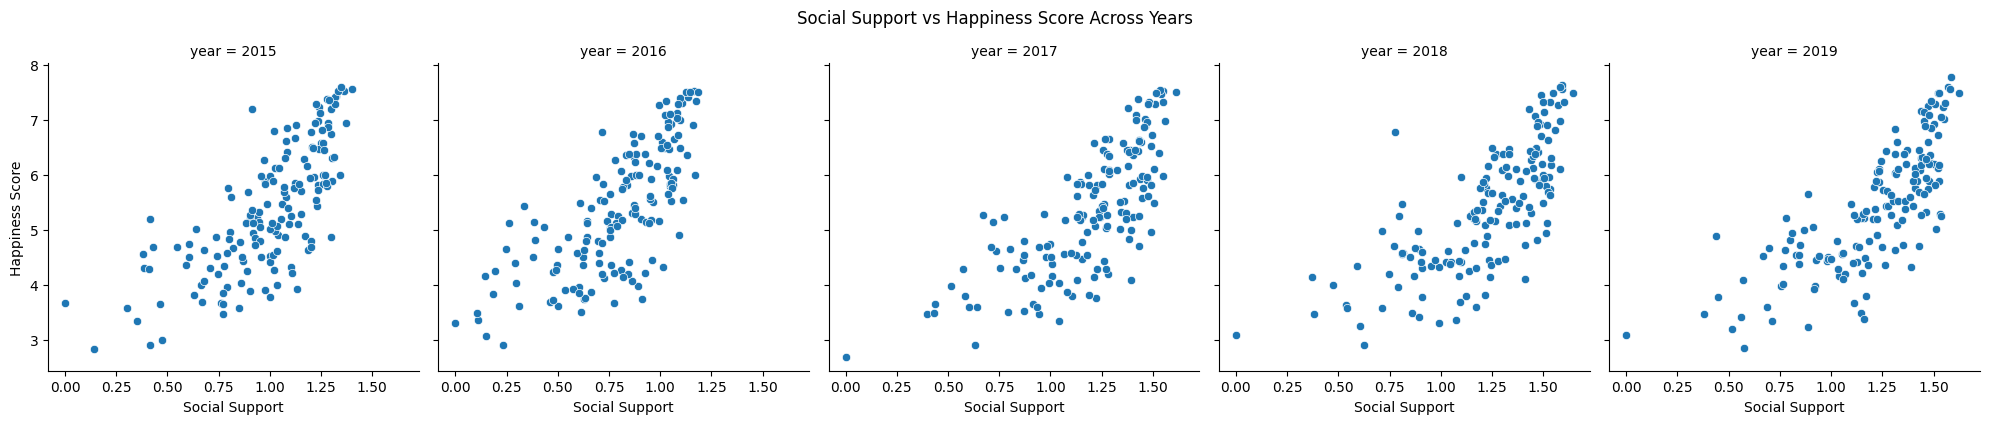

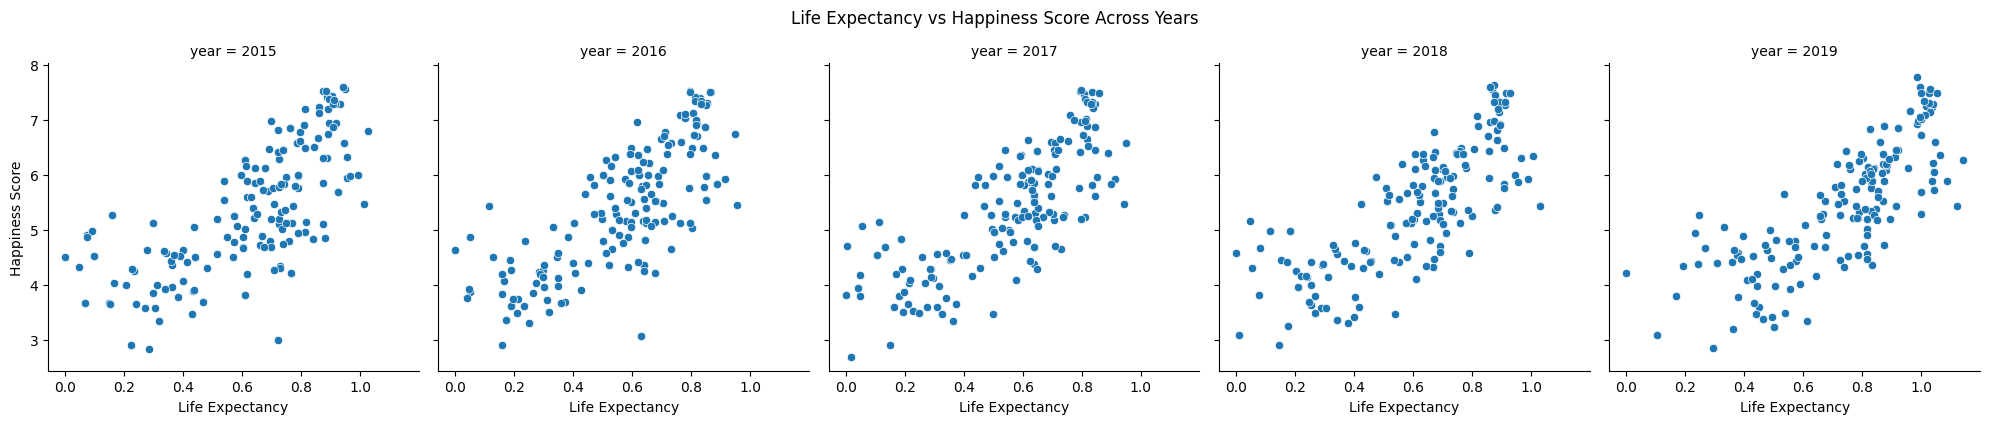

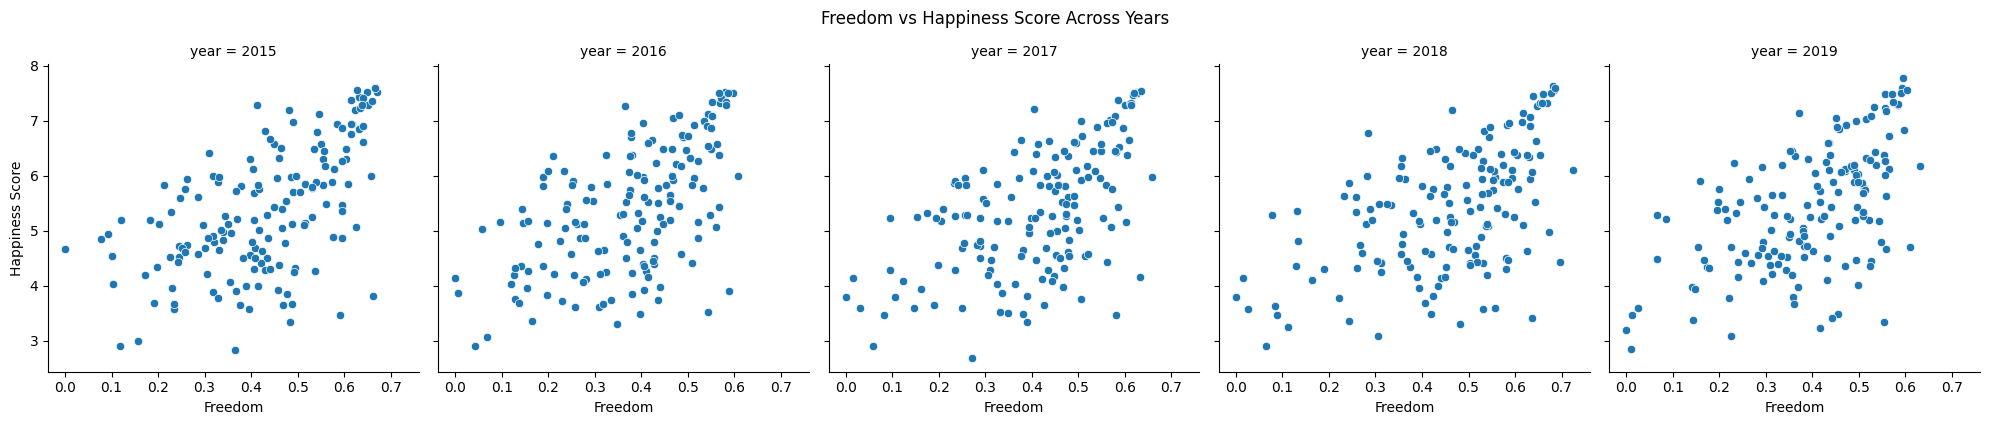

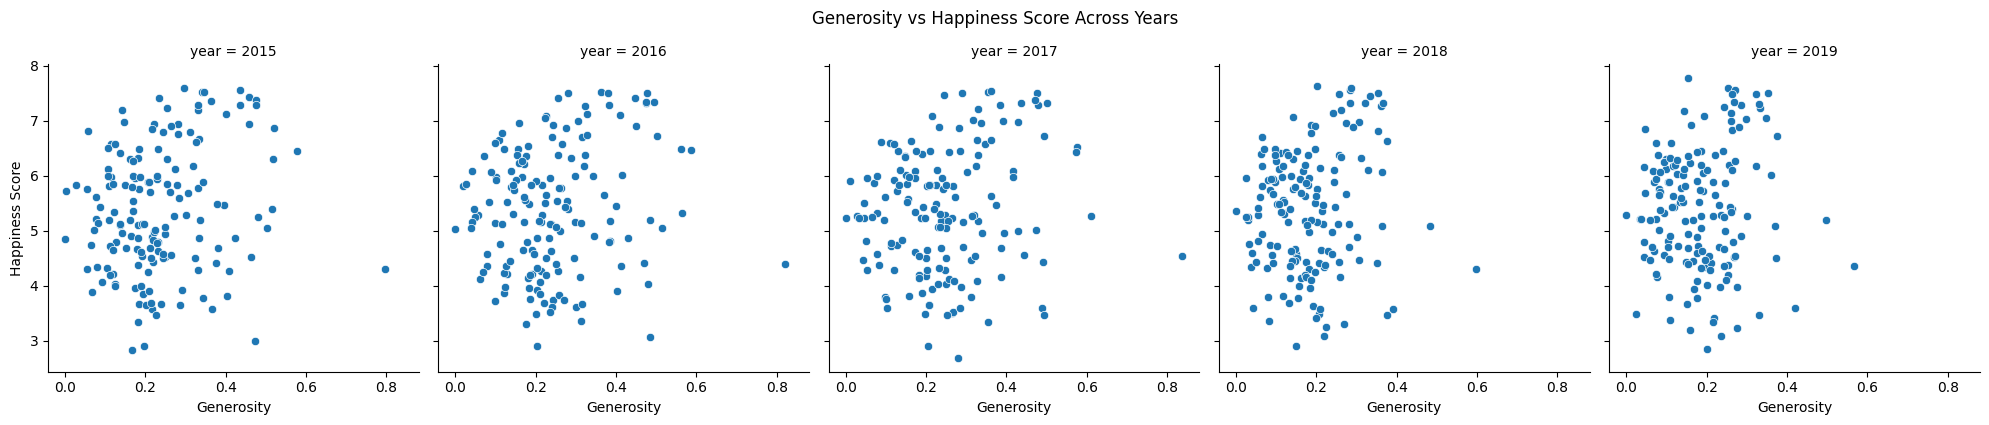

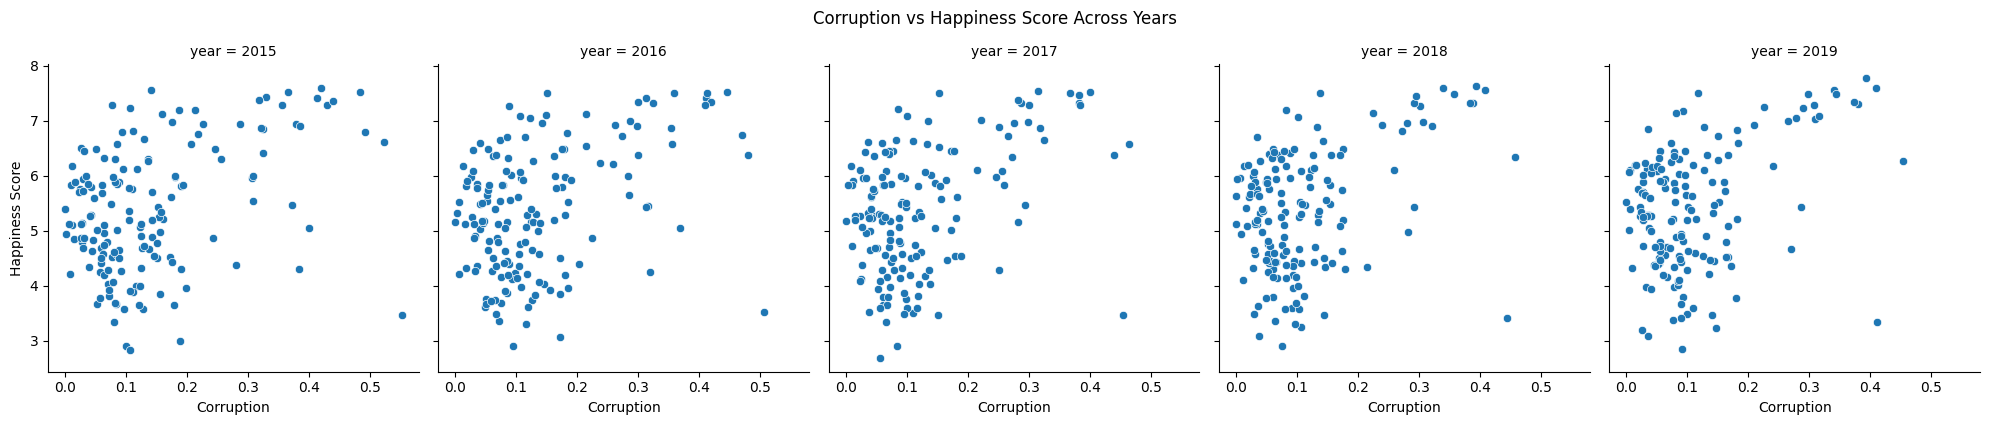

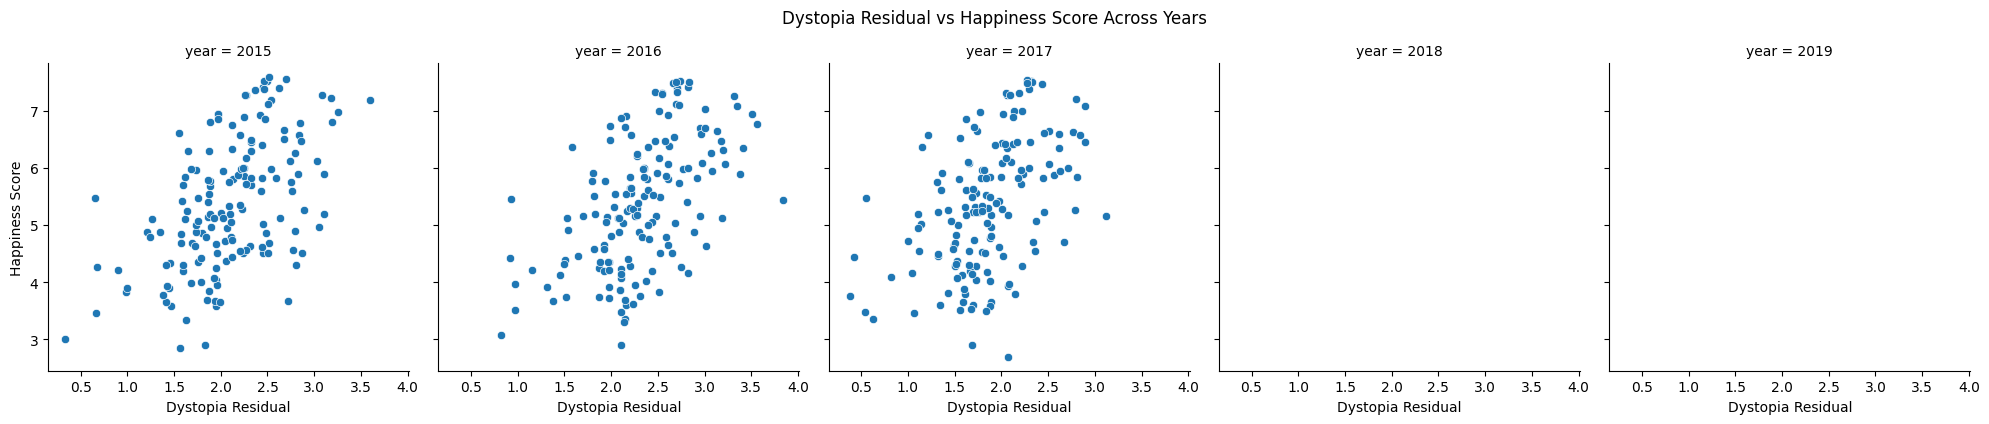

In [23]:
feature_to_plot = "gdp_per_capita"

g = sns.FacetGrid(df, col="year", height=4, aspect=1)
g.map(sns.scatterplot, feature_to_plot, "happiness_score")
g.fig.suptitle(f"{feature_to_plot.replace('_',' ').title()} vs Happiness Score Across Years", y=1.05)
g.set_axis_labels(feature_to_plot.replace('_',' ').title(), "Happiness Score")
plt.show()

# Loop through other features
features = ["social_support", "life_expectancy", "freedom", "generosity", "corruption", "dystopia_residual"]
for feat in features:
    g = sns.FacetGrid(df, col="year", height=4, aspect=1)
    g.map(sns.scatterplot, feat, "happiness_score")
    g.fig.suptitle(f"{feat.replace('_',' ').title()} vs Happiness Score Across Years", y=1.05)
    g.set_axis_labels(feat.replace('_',' ').title(), "Happiness Score")
    plt.show()

Correlation Evolution Over Time

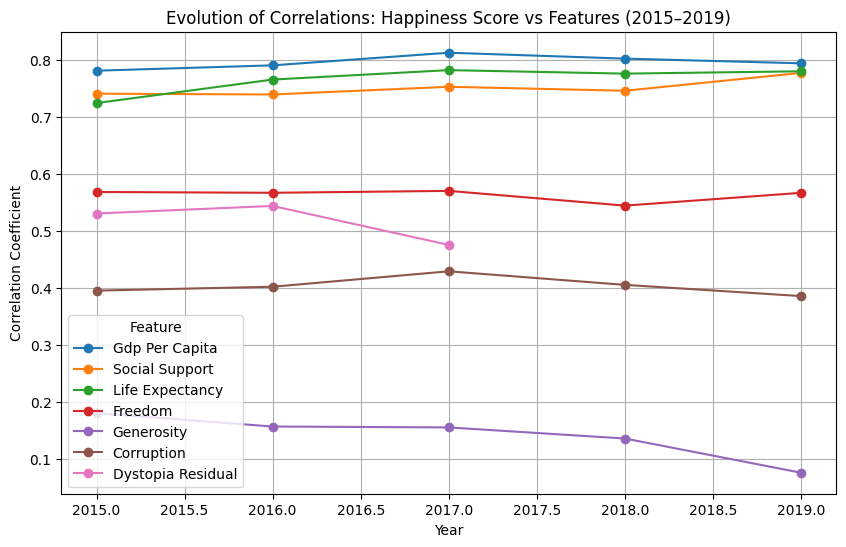

In [24]:
features = ["gdp_per_capita", "social_support", "life_expectancy", "freedom", 
            "generosity", "corruption", "dystopia_residual"]

years = sorted(df['year'].unique())
correlation_dict = {feature: [] for feature in features}

for year in years:
    df_year = df[df['year'] == year]
    for feature in features:
        corr_value = df_year['happiness_score'].corr(df_year[feature])
        correlation_dict[feature].append(corr_value)

plt.figure(figsize=(10, 6))
for feature, corr_values in correlation_dict.items():
    plt.plot(years, corr_values, marker='o', label=feature.replace('_', ' ').title())

plt.title("Evolution of Correlations: Happiness Score vs Features (2015–2019)")
plt.xlabel("Year")
plt.ylabel("Correlation Coefficient")
plt.legend(title="Feature")
plt.grid(True)
plt.show()

## ✅ EDA Complete